In this notebook am going to do some preprocessing on this data set inorder to carry out some time series analysis 


In [10]:
#importing the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt     
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf 


In [11]:
#load the dataset
data = pd.read_csv('ice_cream.csv')
data.head()

,DATE,IPN31152N
0,1972-01-01,59.9622
1,1972-02-01,67.0605
2,1972-03-01,74.2350
3,1972-04-01,78.1120
4,1972-05-01,84.7636


In [12]:
##the dataset has two columns , with abit of abstract names
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 577 entries, 0 to 576
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   DATE       577 non-null    str    
 1   IPN31152N  577 non-null    float64
dtypes: float64(1), str(1)
memory usage: 9.1 KB


In [13]:
#renaming the columns with more meaningful names
data.rename(columns = {'DATE':'date','IPN31152N':'production'}, inplace = True)
data.head()

,date,production
0,1972-01-01,59.9622
1,1972-02-01,67.0605
2,1972-03-01,74.2350
3,1972-04-01,78.1120
4,1972-05-01,84.7636


In [14]:
#changing the format of the date column 
data['date'] = pd.to_datetime(data['date'])
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 577 entries, 0 to 576
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        577 non-null    datetime64[us]
 1   production  577 non-null    float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 9.1 KB


In [ ]:
##setting the date column as the index of the dataframe. This is to make plotting easier
data.set_index('date', inplace = True)
data.head()

,production
date,
1972-01-01,59.9622
1972-02-01,67.0605
1972-03-01,74.2350
1972-04-01,78.1120
1972-05-01,84.7636


In [ ]:
##the dataset contains data all the way from 1974 but ama use data from 2004 to date
start_date = pd.to_datetime('2004-01-01')
data = data[start_date:] #from the start date to the most recent years 
data.head()#now  index in the dictionary only goes from 2004 to 2030

,production
date,
2004-01-01,104.1156
2004-02-01,126.0228
2004-03-01,140.4459
2004-04-01,148.6412
2004-05-01,150.4552


There are two main ways to plot timeseries data using acf(auto correlation function ) and and pacf (partial auto correlation function ) plots. 

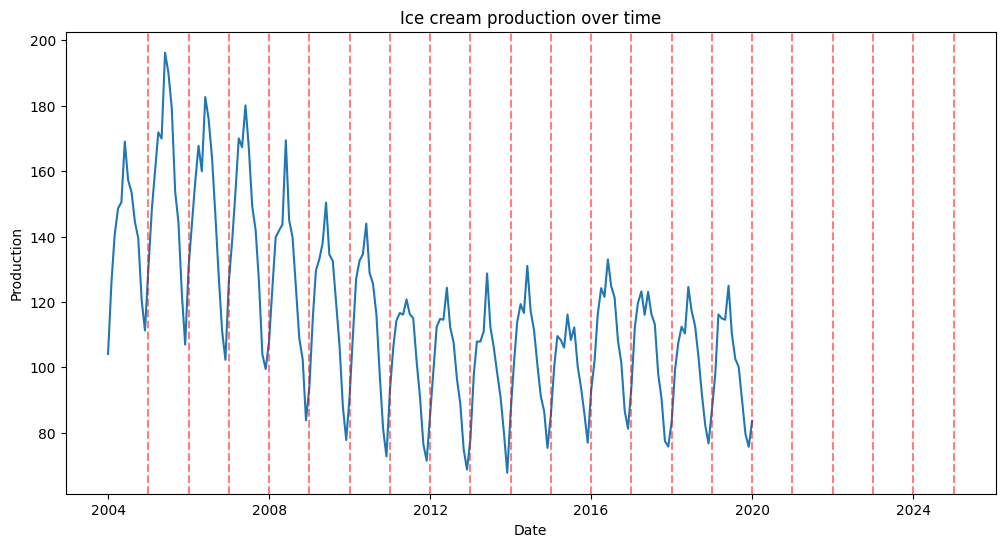

In [17]:
plt.figure(figsize  = (12,6))
plt.plot(data.production)
plt.title("Ice cream production over time")
plt.xlabel("Date")
plt.ylabel("Production")
for year in range(2005, 2026):
    plt.axvline(x = pd.to_datetime(f'{year}-01-01'), color = 'red', linestyle = '--', alpha = 0.5)



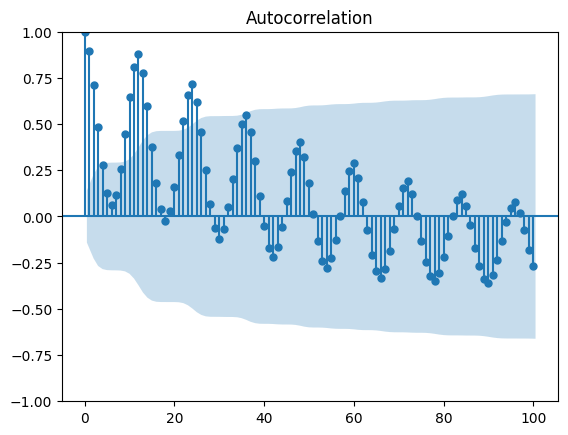

In [18]:
###using the acf plot 
acf_plot = plot_acf(data.production, lags = 100)

This plot shows a decreasing trend over time . A decaying gradient shows an auto regression 


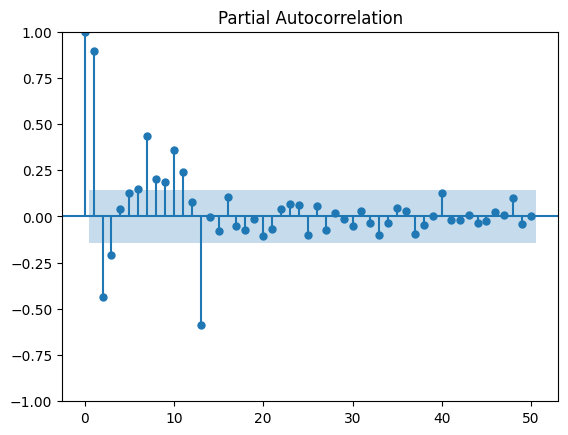

In [20]:
###plotting the pacf to verify our claims

pacf_plot = plot_pacf(data.production, lags = 50)